<a href="https://www.kaggle.com/code/avikdas567/rogii-wellbore-tvt-prediction-lightgbm-ensemble?scriptVersionId=319726329" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# ROGII — Wellbore Geology Prediction

## Strategy

The target is the **TVT** curve in the evaluation zone of each horizontal well.  
The solution uses a hybrid approach:

1. **Per-well geosteering baseline**  
   Fit a local trend from the known `TVT_input` section and extrapolate it through the blind zone.

2. **Geometry + signal features**  
   Use the well path (`MD`, `X`, `Y`, `Z`) and gamma ray (`GR`) to model local deviations.

3. **Typewell-informed similarity features**  
   Add reference-log alignment features from the paired vertical well.

4. **Residual learning**  
   Predict the residual to the local baseline instead of raw TVT directly.

In [1]:
from __future__ import annotations

import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)

HAS_LGBM = False
try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception as e:
    print("lightgbm not available:", e)

print(f"HAS_LGBM={HAS_LGBM}")

HAS_LGBM=True


In [2]:
CANDIDATE_DATA_DIRS = [
    "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
    "/kaggle/input/rogii-wellbore-geology-prediction",
    "/kaggle/input",
]

DATA_DIR = None
for d in CANDIDATE_DATA_DIRS:
    p = Path(d)
    if p.exists() and (p / "train").exists() and (p / "test").exists():
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not find the competition directory. Check the Kaggle input path.")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

print("DATA_DIR:", DATA_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
print("sample_submission exists:", SAMPLE_SUB_PATH.exists())

DATA_DIR: /kaggle/input/competitions/rogii-wellbore-geology-prediction
TRAIN_DIR: /kaggle/input/competitions/rogii-wellbore-geology-prediction/train
TEST_DIR : /kaggle/input/competitions/rogii-wellbore-geology-prediction/test
sample_submission exists: True


## 1. Data inventory

The competition stores each well as a pair of CSV files:

- `*_horizontal_well.csv`
- `*_typewell.csv`

The horizontal log contains the trajectory and the partial `TVT_input` anchor before the prediction start.  
The vertical log is the reference profile used for alignment and signal matching.

In [3]:
def extract_well_id(path: Path | str) -> str:
    return Path(path).stem.split("__")[0]


def list_well_files(split_dir: Path):
    h_files = sorted(split_dir.glob("*__horizontal_well.csv"))
    tw_files = sorted(split_dir.glob("*__typewell*.csv"))
    return h_files, tw_files


HORIZONTAL_KEEP = {
    "MD", "X", "Y", "Z", "GR", "TVT", "TVT_input",
    "ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA",
}
TYPEWELL_KEEP = {"TVT", "GR", "Geology"}


def read_horizontal(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, usecols=lambda c: c in HORIZONTAL_KEEP)
    df.columns = [c.strip() for c in df.columns]
    if "TVT" not in df.columns:
        df["TVT"] = np.nan
    if "TVT_input" not in df.columns:
        df["TVT_input"] = np.nan
    df["well_id"] = extract_well_id(path)
    df["row_id"] = np.arange(len(df), dtype=np.int32)
    return df


def read_typewell(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, usecols=lambda c: c in TYPEWELL_KEEP)
    df.columns = [c.strip() for c in df.columns]
    if "TVT" not in df.columns:
        raise ValueError(f"Typewell file {path} has no TVT column.")
    if "GR" not in df.columns:
        raise ValueError(f"Typewell file {path} has no GR column.")
    if "Geology" not in df.columns:
        df["Geology"] = np.nan
    df["well_id"] = extract_well_id(path)
    df["row_id"] = np.arange(len(df), dtype=np.int32)
    return df


def discover_dataset(split_dir: Path):
    h_files, tw_files = list_well_files(split_dir)
    h_map = {extract_well_id(p): p for p in h_files}
    tw_map = {extract_well_id(p): p for p in tw_files}
    well_ids = sorted(set(h_map) & set(tw_map))
    return well_ids, h_map, tw_map


train_wells, train_h_map, train_tw_map = discover_dataset(TRAIN_DIR)
test_wells, test_h_map, test_tw_map = discover_dataset(TEST_DIR)

sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

print(f"Train wells: {len(train_wells)}")
print(f"Test wells : {len(test_wells)}")
print("Sample submission rows:", len(sample_submission))
display(sample_submission.head())

Train wells: 773
Test wells : 3
Sample submission rows: 14151


,id,tvt
0,000d7d20_1442,0.0
1,000d7d20_1443,0.0
2,000d7d20_1444,0.0
3,000d7d20_1445,0.0
4,000d7d20_1446,0.0


In [4]:
preview_rows = []

for well_id in train_wells[:2]:
    h = read_horizontal(train_h_map[well_id])
    tw = read_typewell(train_tw_map[well_id])
    preview_rows.append({
        "well_id": well_id,
        "h_rows": len(h),
        "tw_rows": len(tw),
        "known_tvt_rows": int(h["TVT_input"].notna().sum()),
        "blind_rows": int(h["TVT_input"].isna().sum()),
        "h_nan_gr": int(h["GR"].isna().sum()),
    })

display(pd.DataFrame(preview_rows))

,well_id,h_rows,tw_rows,known_tvt_rows,blind_rows,h_nan_gr
0,000d7d20,5278,1296,1442,3836,2258
1,00bbac68,7559,1946,1545,6014,942


## 2. Quick EDA

We care about three things:

- **Where does the blind zone begin?**
- **How smooth is the TVT trajectory?**
- **How much signal structure exists in GR?**

The notebook also displays the stored well-path PNGs when they are available, which is useful for a presentation-quality Kaggle writeup.

Example PNGs: ['000d7d20.png', '00bbac68.png', '00e12e8b.png']


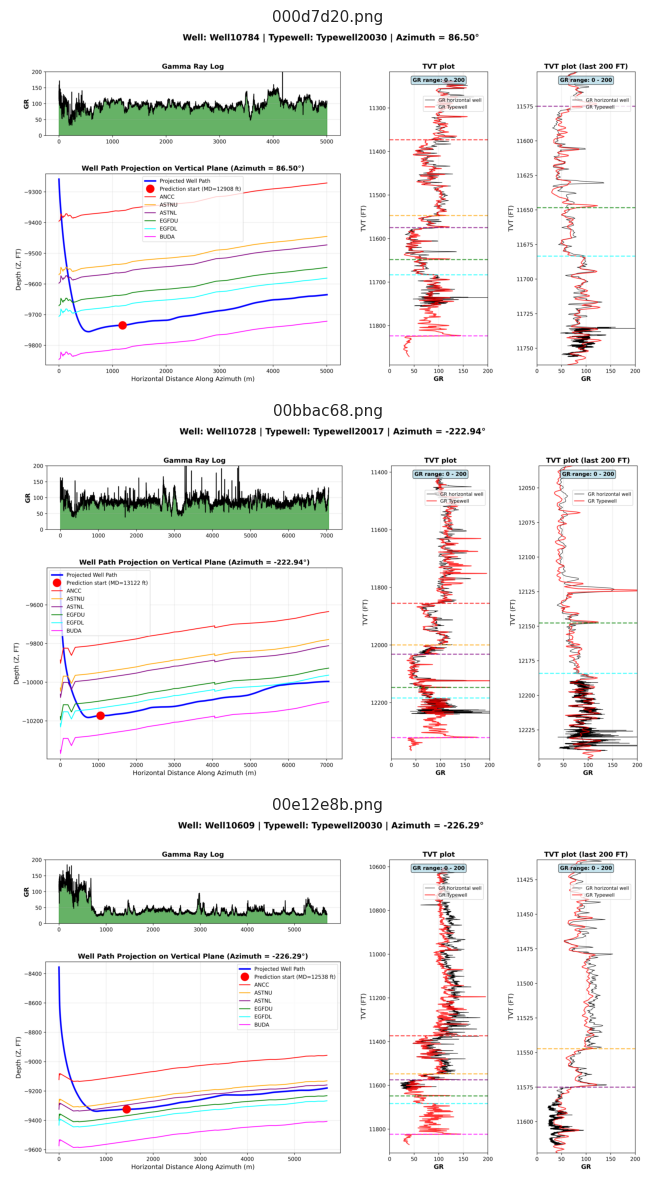

In [5]:
from PIL import Image
from IPython.display import display

def load_example_pngs(split_dir: Path, n=3):
    pngs = sorted(split_dir.glob("*.png"))
    return pngs[:n]

example_pngs = load_example_pngs(TRAIN_DIR, n=3)
print("Example PNGs:", [p.name for p in example_pngs])

fig, axes = plt.subplots(len(example_pngs), 1, figsize=(11, 4 * max(1, len(example_pngs))))
if len(example_pngs) == 1:
    axes = [axes]

for ax, p in zip(axes, example_pngs):
    img = Image.open(p)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(p.name, fontsize=11)

plt.tight_layout()
plt.show()

,well_id,h_rows,known_rows,blind_rows,ps_idx,h_gr_nan,tvt_min,tvt_max
0,000d7d20,5278,1442,3836,1442,2258,11236.02,11756.12
1,00bbac68,7559,1545,6014,1545,942,11406.63,12225.05
2,00e12e8b,6384,2083,4301,2083,584,10606.18,11604.82
3,015fe0d2,5950,1654,4296,1654,1513,11747.26,12241.19
4,01869cd4,6850,1293,5557,1293,3268,11358.27,11745.94
5,01982c1d,5587,1646,3941,1646,846,9927.92,10695.87
6,028d7b28,7761,1527,6234,1527,1691,11874.64,12427.92
7,02e7fe5a,6888,1780,5108,1780,3994,11356.13,12178.98


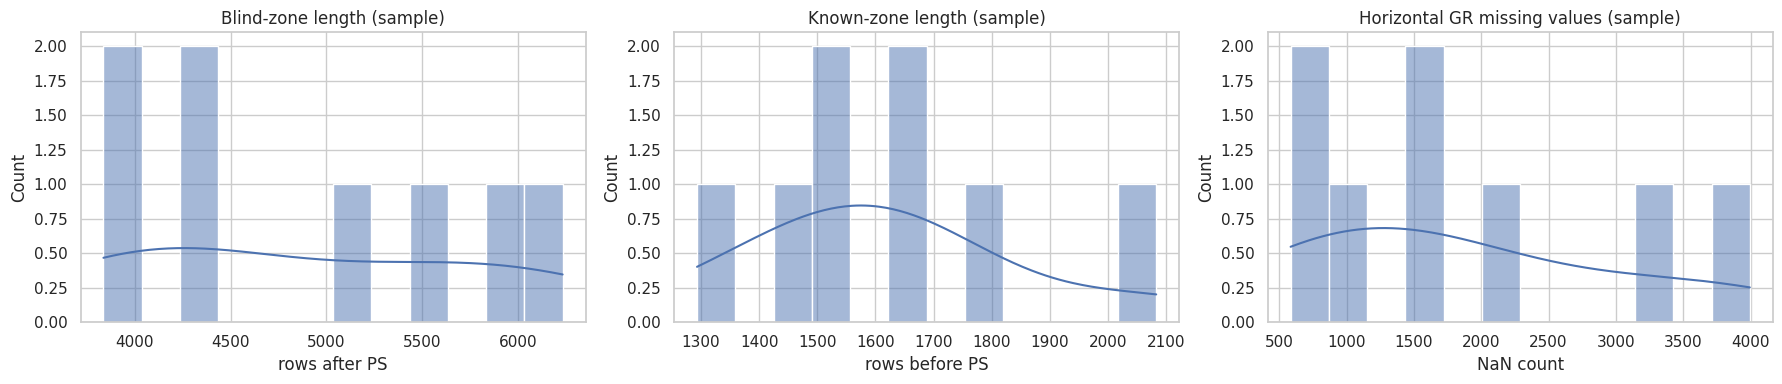

In [6]:
sample_wells = train_wells[:min(8, len(train_wells))]
train_meta = []

for well_id in sample_wells:
    h = read_horizontal(train_h_map[well_id])
    known_mask = h["TVT_input"].notna().to_numpy()
    ps_idx = int(np.argmax(~known_mask)) if (~known_mask).any() else len(h)
    train_meta.append({
        "well_id": well_id,
        "h_rows": len(h),
        "known_rows": int(known_mask.sum()),
        "blind_rows": int((~known_mask).sum()),
        "ps_idx": ps_idx,
        "h_gr_nan": int(h["GR"].isna().sum()),
        "tvt_min": float(h["TVT_input"].min(skipna=True)),
        "tvt_max": float(h["TVT_input"].max(skipna=True)),
    })

train_meta = pd.DataFrame(train_meta)
display(train_meta)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(train_meta["blind_rows"], bins=12, ax=axes[0], kde=True)
axes[0].set_title("Blind-zone length (sample)")
axes[0].set_xlabel("rows after PS")

sns.histplot(train_meta["known_rows"], bins=12, ax=axes[1], kde=True)
axes[1].set_title("Known-zone length (sample)")
axes[1].set_xlabel("rows before PS")

sns.histplot(train_meta["h_gr_nan"], bins=12, ax=axes[2], kde=True)
axes[2].set_title("Horizontal GR missing values (sample)")
axes[2].set_xlabel("NaN count")

plt.tight_layout()
plt.show()

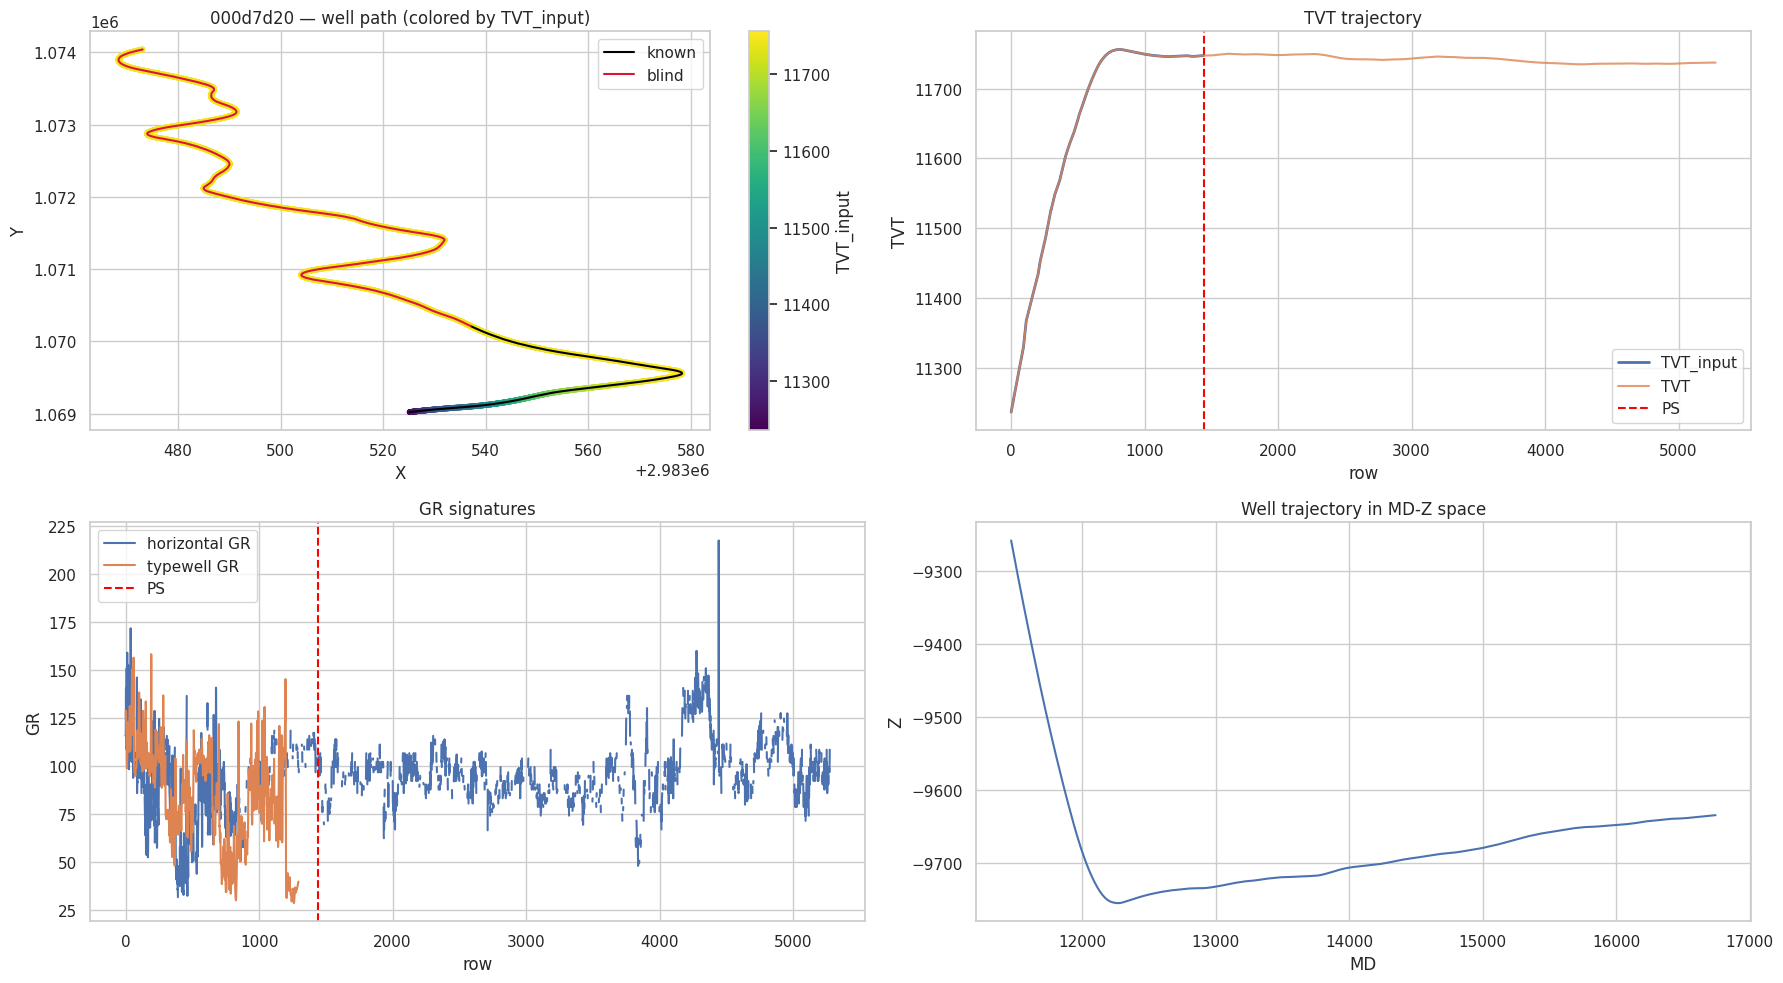

In [7]:
def plot_well_overview(h: pd.DataFrame, tw: pd.DataFrame, well_id: str):
    h = h.sort_values("row_id").reset_index(drop=True).copy()
    tw = tw.sort_values("row_id").reset_index(drop=True).copy()
    known = h["TVT_input"].notna().to_numpy()
    ps_idx = int(np.argmax(~known)) if (~known).any() else len(h)

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    # Map view
    sc = axes[0, 0].scatter(h["X"], h["Y"], c=h["TVT_input"].ffill().bfill(), s=10, cmap="viridis")
    axes[0, 0].plot(h["X"].iloc[:ps_idx], h["Y"].iloc[:ps_idx], color="black", lw=1.5, label="known")
    axes[0, 0].plot(h["X"].iloc[ps_idx:], h["Y"].iloc[ps_idx:], color="crimson", lw=1.5, label="blind")
    axes[0, 0].set_title(f"{well_id} — well path (colored by TVT_input)")
    axes[0, 0].set_xlabel("X")
    axes[0, 0].set_ylabel("Y")
    axes[0, 0].legend()
    plt.colorbar(sc, ax=axes[0, 0], label="TVT_input")

    # TVT over row index
    axes[0, 1].plot(h["row_id"], h["TVT_input"], label="TVT_input", lw=2)
    if "TVT" in h.columns and h["TVT"].notna().any():
        axes[0, 1].plot(h["row_id"], h["TVT"], label="TVT", lw=1.5, alpha=0.8)
    axes[0, 1].axvline(ps_idx, color="red", ls="--", label="PS")
    axes[0, 1].set_title("TVT trajectory")
    axes[0, 1].set_xlabel("row")
    axes[0, 1].set_ylabel("TVT")
    axes[0, 1].legend()

    # GR over row index
    axes[1, 0].plot(h["row_id"], h["GR"], label="horizontal GR", lw=1.5)
    axes[1, 0].plot(tw["row_id"], tw["GR"], label="typewell GR", lw=1.5)
    axes[1, 0].axvline(ps_idx, color="red", ls="--", label="PS")
    axes[1, 0].set_title("GR signatures")
    axes[1, 0].set_xlabel("row")
    axes[1, 0].set_ylabel("GR")
    axes[1, 0].legend()

    # Z vs MD
    axes[1, 1].plot(h["MD"], h["Z"], lw=1.5)
    axes[1, 1].set_title("Well trajectory in MD-Z space")
    axes[1, 1].set_xlabel("MD")
    axes[1, 1].set_ylabel("Z")

    plt.tight_layout()
    plt.show()

example_well = train_wells[0]
plot_well_overview(read_horizontal(train_h_map[example_well]), read_typewell(train_tw_map[example_well]), example_well)

## 3. Feature engineering

The model is trained on the **blind zone only** (`TVT_input` is NaN there), because that is the exact inference regime.

We build three feature groups:

1. **Local trajectory features**
   - `MD`, `X`, `Y`, `Z`
   - derivatives and step sizes
   - curvature / angle proxy features

2. **Signal features**
   - GR smoothing
   - rolling statistics
   - short/medium differences
   - GR z-score within the well

3. **Contextual priors**
   - local linear extrapolation from known TVT
   - typewell signature features
   - GR similarity to the paired vertical reference log

In [8]:
def weighted_linear_baseline(md_known: np.ndarray, tvt_known: np.ndarray, md_all: np.ndarray) -> tuple[np.ndarray, dict]:
    # Fast baseline: weighted linear fit on the tail of the known TVT_input section.
    md_known = np.asarray(md_known, dtype=float)
    tvt_known = np.asarray(tvt_known, dtype=float)
    md_all = np.asarray(md_all, dtype=float)

    mask = np.isfinite(md_known) & np.isfinite(tvt_known)
    md_known = md_known[mask]
    tvt_known = tvt_known[mask]

    if len(md_known) < 4:
        const = float(np.nanmedian(tvt_known)) if len(tvt_known) else np.nan
        pred = np.full_like(md_all, const, dtype=float)
        return pred, {"slope": 0.0, "intercept": const, "n_tail": len(md_known)}

    tail_len = min(max(16, len(md_known) // 5), 128, len(md_known))
    md_tail = md_known[-tail_len:]
    tvt_tail = tvt_known[-tail_len:]

    # Heavier weights closer to the prediction start.
    w = np.linspace(0.4, 1.0, tail_len)
    slope, intercept = np.polyfit(md_tail, tvt_tail, 1, w=w)
    pred = slope * md_all + intercept

    return pred, {
        "slope": float(slope),
        "intercept": float(intercept),
        "n_tail": int(tail_len),
    }


def make_typewell_features_fast(h: pd.DataFrame, tw: pd.DataFrame, baseline_tvt: np.ndarray) -> dict:
    # Lightweight typewell summary features.
    tw = tw.copy()
    tw["GR"] = pd.to_numeric(tw["GR"], errors="coerce")
    tw["TVT"] = pd.to_numeric(tw["TVT"], errors="coerce")
    tw = tw.dropna(subset=["GR", "TVT"]).sort_values("TVT")

    if len(tw) < 3:
        return {
            "tw_len": len(tw),
            "tw_tvt_min": np.nan,
            "tw_tvt_max": np.nan,
            "tw_tvt_span": np.nan,
            "tw_gr_mean": np.nan,
            "tw_gr_std": np.nan,
            "tw_gr_min": np.nan,
            "tw_gr_max": np.nan,
            "tw_corr_resamp": np.nan,
            "tw_best_lag": np.nan,
            "tw_gr_at_base": np.nan,
        }

    tw_tvt = tw["TVT"].to_numpy(dtype=float)
    tw_gr = tw["GR"].interpolate(limit_direction="both").to_numpy(dtype=float)

    tw_tvt_u, uidx = np.unique(tw_tvt, return_index=True)
    tw_gr_u = tw_gr[uidx]

    base_scalar = float(np.nanmedian(baseline_tvt))
    tw_gr_at_base = float(
        np.interp(
            np.clip(base_scalar, tw_tvt_u.min(), tw_tvt_u.max()),
            tw_tvt_u,
            tw_gr_u,
            left=tw_gr_u[0],
            right=tw_gr_u[-1],
        )
    )

    pre_mask = h["TVT_input"].notna().to_numpy()
    h_gr_pre = pd.to_numeric(h.loc[pre_mask, "GR"], errors="coerce").interpolate(limit_direction="both").to_numpy(dtype=float)

    if len(h_gr_pre) >= 8 and len(tw_gr_u) >= 8:
        n = 128
        h_rs = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(h_gr_pre)), h_gr_pre)
        t_rs = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(tw_gr_u)), tw_gr_u)

        h_rs = (h_rs - h_rs.mean()) / (h_rs.std() + 1e-6)
        t_rs = (t_rs - t_rs.mean()) / (t_rs.std() + 1e-6)

        corr0 = float(np.corrcoef(h_rs, t_rs)[0, 1]) if np.isfinite(np.corrcoef(h_rs, t_rs)[0, 1]) else np.nan
        best_corr, best_lag = corr0, 0
        for lag in range(-6, 7):
            if lag < 0:
                a, b = h_rs[:lag], t_rs[-lag:]
            elif lag > 0:
                a, b = h_rs[lag:], t_rs[:-lag]
            else:
                a, b = h_rs, t_rs
            if len(a) < 16 or len(b) < 16:
                continue
            c = np.corrcoef(a, b)[0, 1]
            if np.isfinite(c) and (not np.isfinite(best_corr) or c > best_corr):
                best_corr, best_lag = float(c), int(lag)
    else:
        best_corr, best_lag = np.nan, np.nan

    return {
        "tw_len": len(tw),
        "tw_tvt_min": float(np.nanmin(tw_tvt_u)),
        "tw_tvt_max": float(np.nanmax(tw_tvt_u)),
        "tw_tvt_span": float(np.nanmax(tw_tvt_u) - np.nanmin(tw_tvt_u)),
        "tw_gr_mean": float(np.nanmean(tw_gr_u)),
        "tw_gr_std": float(np.nanstd(tw_gr_u)),
        "tw_gr_min": float(np.nanmin(tw_gr_u)),
        "tw_gr_max": float(np.nanmax(tw_gr_u)),
        "tw_corr_resamp": best_corr,
        "tw_best_lag": best_lag,
        "tw_gr_at_base": tw_gr_at_base,
    }


def build_well_features(h: pd.DataFrame, tw: pd.DataFrame | None, is_train: bool):
    # Fast, vectorized feature builder.
    h = h.sort_values("row_id").reset_index(drop=True).copy()

    for c in ["MD", "X", "Y", "Z", "GR", "TVT_input", "TVT"]:
        if c in h.columns:
            h[c] = pd.to_numeric(h[c], errors="coerce")

    known_mask = h["TVT_input"].notna().to_numpy()
    ps_idx = int(np.argmax(~known_mask)) if (~known_mask).any() else len(h)

    baseline_tvt, baseline_info = weighted_linear_baseline(
        md_known=h.loc[known_mask, "MD"].to_numpy(),
        tvt_known=h.loc[known_mask, "TVT_input"].to_numpy(),
        md_all=h["MD"].to_numpy(),
    )

    h["GR_filled"] = h["GR"].interpolate(limit_direction="both").ffill().bfill()
    h["md_rel"] = h["MD"] - h["MD"].iloc[0]
    h["md_norm"] = h["md_rel"] / (h["md_rel"].max() + 1e-6)
    h["row_norm"] = h["row_id"] / max(1, len(h) - 1)
    h["known_mask"] = known_mask.astype(np.int8)
    h["dist_from_ps"] = np.arange(len(h)) - ps_idx
    h["dist_from_ps_abs"] = np.abs(h["dist_from_ps"])
    h["post_ps"] = (h["dist_from_ps"] >= 0).astype(np.int8)

    for col in ["X", "Y", "Z"]:
        h[f"{col}_diff"] = h[col].diff().fillna(0.0)
        h[f"{col}_absdiff"] = h[f"{col}_diff"].abs()

    h["xy_step"] = np.sqrt(h["X_diff"] ** 2 + h["Y_diff"] ** 2)
    h["dz_step"] = h["Z_diff"]
    h["path_step"] = np.sqrt(h["X_diff"] ** 2 + h["Y_diff"] ** 2 + h["Z_diff"] ** 2)
    h["path_length"] = h["path_step"].cumsum()
    h["azimuth"] = np.degrees(np.arctan2(h["Y_diff"], h["X_diff"]))
    h["dip_proxy"] = np.degrees(np.arctan2(h["dz_step"].abs(), h["xy_step"] + 1e-6))
    h["z_change_from_start"] = h["Z"] - h["Z"].iloc[0]
    h["md_from_ps"] = h["MD"] - h["MD"].iloc[min(ps_idx, len(h) - 1)]
    h["z_from_ps"] = h["Z"] - h["Z"].iloc[min(ps_idx, len(h) - 1)]

    # Very cheap GR features.
    for w in (5, 11):
        h[f"gr_roll_mean_{w}"] = h["GR_filled"].rolling(w, min_periods=1, center=True).mean()
        h[f"gr_roll_std_{w}"] = h["GR_filled"].rolling(w, min_periods=1, center=True).std().fillna(0.0)
    h["gr_diff_1"] = h["GR_filled"].diff().fillna(0.0)
    h["gr_diff_3"] = h["GR_filled"].diff(3).fillna(0.0)
    h["gr_ema_8"] = h["GR_filled"].ewm(span=8, adjust=False).mean()
    h["gr_zscore"] = (h["GR_filled"] - h["GR_filled"].mean()) / (h["GR_filled"].std() + 1e-6)
    h["gr_pct_rank"] = h["GR_filled"].rank(pct=True)
    h["gr_resid_ema"] = h["GR_filled"] - h["gr_ema_8"]

    h["known_tvt_input"] = h["TVT_input"].ffill().bfill()
    h["known_tvt_last"] = h["TVT_input"].ffill()
    h["known_tvt_first"] = h["TVT_input"].bfill()
    h["known_tvt_count"] = int(known_mask.sum())
    h["known_tvt_frac"] = float(known_mask.mean())
    h["known_tvt_span"] = float(np.nanmax(h.loc[known_mask, "TVT_input"]) - np.nanmin(h.loc[known_mask, "TVT_input"])) if known_mask.any() else np.nan

    h["baseline_tvt"] = baseline_tvt
    h["baseline_offset"] = h["baseline_tvt"] - h["known_tvt_last"].fillna(h["baseline_tvt"].iloc[0])
    h["baseline_slope"] = baseline_info["slope"]
    h["baseline_intercept"] = baseline_info["intercept"]
    h["ps_idx"] = ps_idx
    h["ps_frac"] = ps_idx / max(1, len(h) - 1)
    h["known_len"] = ps_idx
    h["blind_len"] = len(h) - ps_idx

    if tw is not None:
        tw_feat = make_typewell_features_fast(h, tw, baseline_tvt)
        for k, v in tw_feat.items():
            h[k] = v
    else:
        h["tw_len"] = np.nan
        h["tw_tvt_min"] = np.nan
        h["tw_tvt_max"] = np.nan
        h["tw_tvt_span"] = np.nan
        h["tw_gr_mean"] = np.nan
        h["tw_gr_std"] = np.nan
        h["tw_gr_min"] = np.nan
        h["tw_gr_max"] = np.nan
        h["tw_corr_resamp"] = np.nan
        h["tw_best_lag"] = np.nan
        h["tw_gr_at_base"] = np.nan

    # Light-weight prior. Keep it close to the anchored baseline for stability and speed.
    h["prior_combo"] = h["baseline_tvt"]
    h["prior_residual"] = h["baseline_tvt"] - h["prior_combo"]
    h["gr_minus_typewell"] = h["GR_filled"] - h["tw_gr_at_base"].fillna(h["GR_filled"].median())
    h["baseline_delta_from_last_known"] = h["baseline_tvt"] - h["known_tvt_last"].ffill().bfill()

    train_mask = np.arange(len(h)) >= ps_idx
    return h, train_mask, baseline_tvt


def summarize_well(h: pd.DataFrame):
    known = h["TVT_input"].notna().to_numpy()
    ps_idx = int(np.argmax(~known)) if (~known).any() else len(h)
    return {
        "rows": len(h),
        "known_rows": int(known.sum()),
        "blind_rows": int(len(h) - known.sum()),
        "ps_idx": ps_idx,
        "gr_nan": int(h["GR"].isna().sum()),
    }

In [9]:
# Build the full training table.
train_frames = []

for well_id in train_wells:
    h = read_horizontal(train_h_map[well_id])
    tw = read_typewell(train_tw_map[well_id])
    feat, train_mask, baseline = build_well_features(h, tw, is_train=True)

    blind_rows = feat.loc[train_mask].copy()
    if "TVT" not in blind_rows.columns:
        raise ValueError(f"Training file for well {well_id} does not contain TVT target.")

    blind_rows["target_tvt"] = pd.to_numeric(blind_rows["TVT"], errors="coerce")
    blind_rows["target_residual"] = blind_rows["target_tvt"] - blind_rows["prior_combo"]
    blind_rows["well_id"] = well_id

    # Keep only useful columns to reduce memory and speed up downstream processing.
    train_frames.append(blind_rows)

train_df = pd.concat(train_frames, ignore_index=True, copy=False)
print("Training rows in blind zone:", len(train_df))
display(train_df[["well_id", "row_id", "MD", "GR", "baseline_tvt", "prior_combo", "target_tvt", "target_residual"]].head())

Training rows in blind zone: 3783989


,well_id,row_id,MD,GR,baseline_tvt,prior_combo,target_tvt,target_residual
0,000d7d20,1442,12909.0,NaN,11747.184760,11747.184760,11747.38,0.195240
1,000d7d20,1443,12910.0,NaN,11747.192812,11747.192812,11747.39,0.197188
2,000d7d20,1444,12911.0,NaN,11747.200863,11747.200863,11747.40,0.199137
3,000d7d20,1445,12912.0,104.818205,11747.208914,11747.208914,11747.40,0.191086
4,000d7d20,1446,12913.0,103.960888,11747.216966,11747.216966,11747.41,0.193034


In [10]:
# Feature columns for the residual model.
drop_cols = {
    "TVT", "TVT_input", "target_tvt", "target_residual",
    "source", "well_id", "row_id"
}

candidate_features = [c for c in train_df.columns if c not in drop_cols]

feature_cols = []
for c in candidate_features:
    if pd.api.types.is_numeric_dtype(train_df[c]):
        feature_cols.append(c)

print(f"Feature count: {len(feature_cols)}")
print(feature_cols[:30])

Feature count: 73
['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'GR', 'GR_filled', 'md_rel', 'md_norm', 'row_norm', 'known_mask', 'dist_from_ps', 'dist_from_ps_abs', 'post_ps', 'X_diff', 'X_absdiff', 'Y_diff', 'Y_absdiff', 'Z_diff', 'Z_absdiff', 'xy_step', 'dz_step', 'path_step', 'path_length', 'azimuth']


## 4. Cross-validation

We use **GroupKFold by well id** so that the model is forced to generalize to unseen wells.

The final prediction is the **baseline TVT** plus the predicted **residual**.

All-NaN feature columns: ['known_tvt_first']
Fold 1/3 | train=2523029 val=1260960
  baseline RMSE: 119.11831
  model    RMSE: 37.94307

Fold 2/3 | train=2522677 val=1261312
  baseline RMSE: 101.56802
  model    RMSE: 22.28136

Fold 3/3 | train=2522272 val=1261717
  baseline RMSE: 130.77008
  model    RMSE: 36.31233

Overall CV baseline RMSE: 117.766716
Overall CV model    RMSE: 32.937804


,fold,baseline_rmse,model_rmse
0,1,119.118311,37.943072
1,2,101.568022,22.281357
2,3,130.770083,36.312328


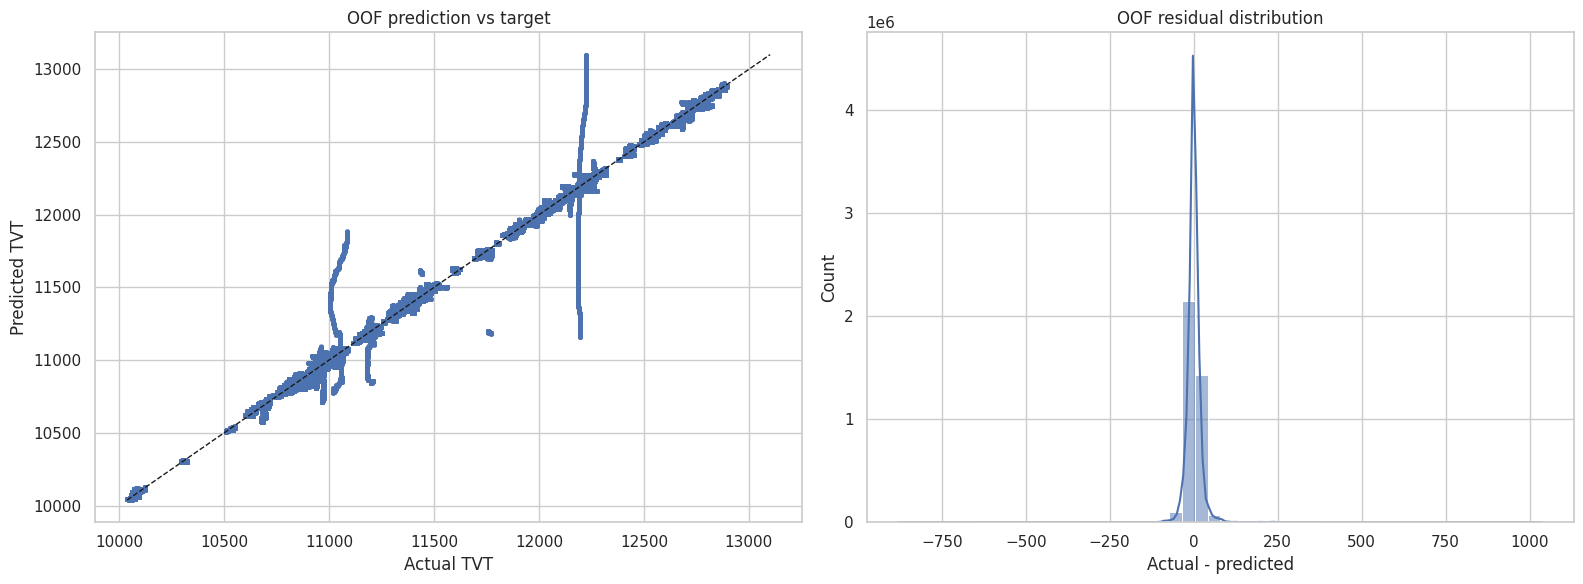

In [11]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def fit_lgbm(X_train, y_train, X_val, y_val):

    model = lgb.LGBMRegressor(
        n_estimators=1500,
        learning_rate=0.04,
        num_leaves=64,
        max_depth=-1,
        min_child_samples=25,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.9,
        reg_alpha=0.5,
        reg_lambda=2.0,
        random_state=SEED,
        n_jobs=-1,
        force_col_wise=True,
        verbosity=-1,
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=50,
                verbose=False
            )
        ]
    )

    return model


# ---------------------------------------------------------
# CLEAN FEATURE MATRIX
# ---------------------------------------------------------

# Remove fully empty / broken columns
feature_cols = [
    c for c in feature_cols
    if c in train_df.columns
]

X = train_df.reindex(columns=feature_cols).copy()

# Convert everything numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove all-NaN columns
empty_cols = X.columns[X.isna().all()].tolist()

if len(empty_cols) > 0:
    print("All-NaN feature columns:", empty_cols)

    X = X.drop(columns=empty_cols)

    feature_cols = [
        c for c in feature_cols
        if c not in empty_cols
    ]

# Fast median imputation
X_imp = X.fillna(
    X.median(numeric_only=True)
)

# Remaining NaNs -> 0
X_imp = X_imp.fillna(0.0)

# Compact memory
X_imp = X_imp.astype(np.float32)

y = train_df["target_residual"].astype(np.float32).values
groups = train_df["well_id"].values


# ---------------------------------------------------------
# CROSS VALIDATION
# ---------------------------------------------------------

n_splits = min(
    3,
    train_df["well_id"].nunique()
)

gkf = GroupKFold(
    n_splits=n_splits
)

oof_pred_resid = np.zeros(
    len(train_df),
    dtype=np.float32
)

fold_models = []
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(
    gkf.split(X_imp, y, groups=groups),
    1
):

    X_tr = X_imp.iloc[tr_idx]
    X_va = X_imp.iloc[va_idx]

    y_tr = y[tr_idx]
    y_va = y[va_idx]

    print(
        f"Fold {fold}/{n_splits} | "
        f"train={len(tr_idx)} "
        f"val={len(va_idx)}"
    )

    model = fit_lgbm(
        X_tr,
        y_tr,
        X_va,
        y_va
    )

    best_iter = getattr(
        model,
        "best_iteration_",
        None
    )

    pred_resid = model.predict(
        X_va,
        num_iteration=best_iter
    )

    oof_pred_resid[va_idx] = pred_resid

    fold_models.append(model)

    pred_tvt = (
        train_df.loc[va_idx, "prior_combo"].values
        + pred_resid
    )

    target_true = train_df.loc[
        va_idx,
        "target_tvt"
    ].values

    baseline_pred = train_df.loc[
        va_idx,
        "prior_combo"
    ].values

    rmse_model = rmse(
        target_true,
        pred_tvt
    )

    rmse_base = rmse(
        target_true,
        baseline_pred
    )

    fold_scores.append(
        (
            fold,
            rmse_base,
            rmse_model
        )
    )

    print(
        f"  baseline RMSE: {rmse_base:.5f}"
    )

    print(
        f"  model    RMSE: {rmse_model:.5f}"
    )

    print()


# ---------------------------------------------------------
# OVERALL METRICS
# ---------------------------------------------------------

oof_pred = (
    train_df["prior_combo"].values
    + oof_pred_resid
)

cv_rmse = rmse(
    train_df["target_tvt"].values,
    oof_pred
)

cv_baseline = rmse(
    train_df["target_tvt"].values,
    train_df["prior_combo"].values
)

print(
    "Overall CV baseline RMSE:",
    round(cv_baseline, 6)
)

print(
    "Overall CV model    RMSE:",
    round(cv_rmse, 6)
)

display(
    pd.DataFrame(
        fold_scores,
        columns=[
            "fold",
            "baseline_rmse",
            "model_rmse"
        ]
    )
)


# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

axes[0].scatter(
    train_df["target_tvt"],
    oof_pred,
    s=6,
    alpha=0.35
)

lo = min(
    train_df["target_tvt"].min(),
    oof_pred.min()
)

hi = max(
    train_df["target_tvt"].max(),
    oof_pred.max()
)

axes[0].plot(
    [lo, hi],
    [lo, hi],
    "k--",
    lw=1
)

axes[0].set_title(
    "OOF prediction vs target"
)

axes[0].set_xlabel(
    "Actual TVT"
)

axes[0].set_ylabel(
    "Predicted TVT"
)

residual_err = (
    train_df["target_tvt"].values
    - oof_pred
)

sns.histplot(
    residual_err,
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title(
    "OOF residual distribution"
)

axes[1].set_xlabel(
    "Actual - predicted"
)

plt.tight_layout()
plt.show()

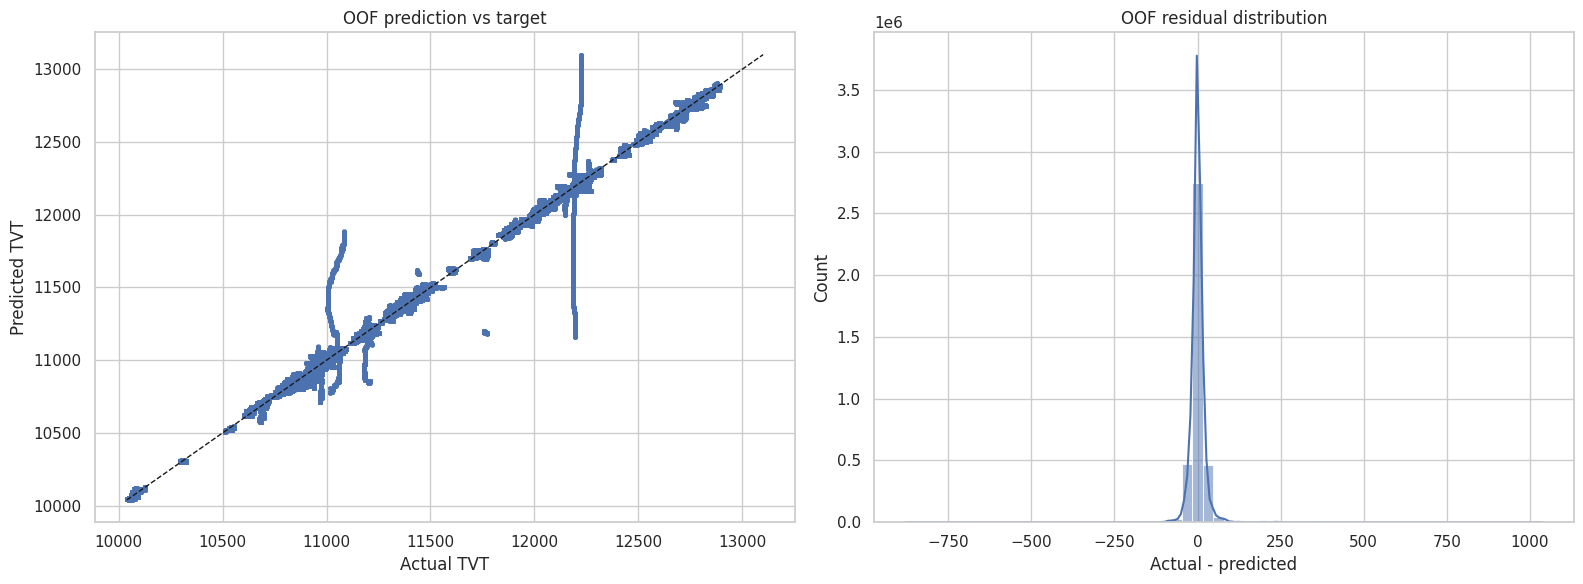

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(train_df["target_tvt"], oof_pred, s=6, alpha=0.35)
lo = min(train_df["target_tvt"].min(), oof_pred.min())
hi = max(train_df["target_tvt"].max(), oof_pred.max())
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].set_title("OOF prediction vs target")
axes[0].set_xlabel("Actual TVT")
axes[0].set_ylabel("Predicted TVT")

residual_err = train_df["target_tvt"].values - oof_pred
sns.histplot(residual_err, bins=60, kde=True, ax=axes[1])
axes[1].set_title("OOF residual distribution")
axes[1].set_xlabel("Actual - predicted")

plt.tight_layout()
plt.show()

In [13]:
# Keep the fold models as the final ensemble. This avoids an expensive refit on the full training set.
final_models = fold_models
print("Final model count:", len(final_models))

Final model count: 3


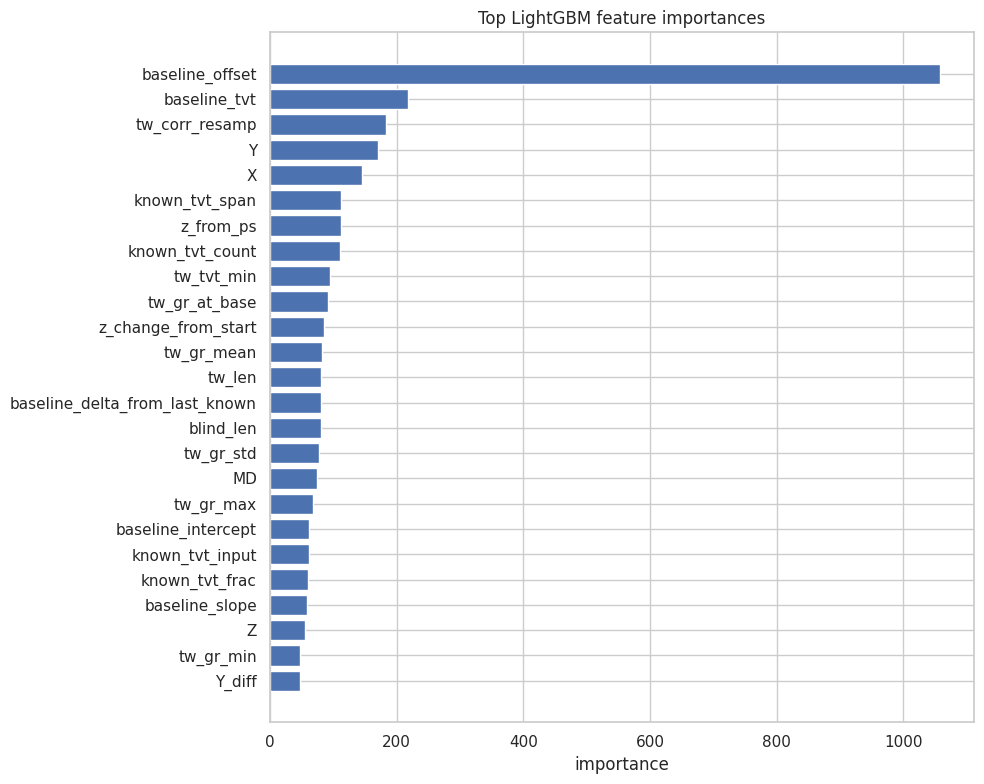

,feature,importance
50,baseline_offset,1059
49,baseline_tvt,218
65,tw_corr_resamp,183
2,Y,170
1,X,145
33,z_from_ps,112
48,known_tvt_span,112
46,known_tvt_count,110
58,tw_tvt_min,95
67,tw_gr_at_base,92


In [14]:
if final_models:
    lgbm_model = final_models[0]
    importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": getattr(lgbm_model, "feature_importances_", np.zeros(len(feature_cols))),
    }).sort_values("importance", ascending=False)

    top_imp = importance.head(25).sort_values("importance")

    plt.figure(figsize=(10, 8))
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.title("Top LightGBM feature importances")
    plt.xlabel("importance")
    plt.tight_layout()
    plt.show()

    display(importance.head(20))

## 5. Inference

At inference time:

- the known `TVT_input` section is used to build the local baseline,
- the feature engineering is applied to the full well,
- the residual model predicts the blind zone,
- the final answer is `baseline + residual`.

The competition submission must be saved as **`submission.csv`**.

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# STORE TRAIN MEDIANS
# ---------------------------------------------------------

# Use the exact columns used during training
model_feature_cols = list(X_imp.columns)

# Store training medians for inference
train_feature_medians = X_imp.median(numeric_only=True)


# ---------------------------------------------------------
# TEST PREDICTION FUNCTION
# ---------------------------------------------------------

def build_test_predictions(
    h_path: Path,
    tw_path: Path,
    models: list,
    feature_cols: list[str],
):

    h = read_horizontal(h_path)
    tw = read_typewell(tw_path)

    feat, blind_mask, baseline_tvt = build_well_features(
        h,
        tw,
        is_train=False
    )

    rows = feat.loc[blind_mask].copy()

    # Submission IDs
    row_ids = rows["row_id"].astype(int).to_numpy()
    well_id = feat["well_id"].iloc[0]

    ids = [
        f"{well_id}_{rid}"
        for rid in row_ids
    ]

    # ---------------------------------------------------------
    # FEATURE ALIGNMENT
    # ---------------------------------------------------------

    # Recreate exact train feature layout
    X_test = rows.reindex(
        columns=model_feature_cols
    ).copy()

    # Numeric coercion
    X_test = X_test.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Median fill using TRAIN medians
    X_test = X_test.fillna(
        train_feature_medians
    )

    # Remaining NaNs -> 0
    X_test = X_test.fillna(0.0)

    # Match training dtype
    X_test = X_test.astype(np.float32)

    # ---------------------------------------------------------
    # ENSEMBLE PREDICTION
    # ---------------------------------------------------------

    preds = []

    for model in models:

        best_iter = getattr(
            model,
            "best_iteration_",
            None
        )

        pred = model.predict(
            X_test,
            num_iteration=best_iter
        )

        preds.append(pred)

    pred_resid = (
        np.mean(
            np.column_stack(preds),
            axis=1
        )
        if len(preds)
        else np.zeros(
            len(rows),
            dtype=np.float32
        )
    )

    pred_tvt = (
        rows["prior_combo"].values
        + pred_resid
    )

    out = pd.DataFrame({
        "id": ids,
        "tvt": pred_tvt
    })

    return out, feat


# ---------------------------------------------------------
# RUN INFERENCE
# ---------------------------------------------------------

test_predictions = []
example_test_features = None

for well_id in test_wells:

    pred_df, feat_df = build_test_predictions(
        test_h_map[well_id],
        test_tw_map[well_id],
        final_models,
        model_feature_cols,
    )

    test_predictions.append(pred_df)

    if example_test_features is None:
        example_test_features = feat_df


# ---------------------------------------------------------
# BUILD SUBMISSION
# ---------------------------------------------------------

submission = pd.concat(
    test_predictions,
    ignore_index=True
)

submission = sample_submission[
    ["id"]
].merge(
    submission,
    on="id",
    how="left"
)

assert submission["tvt"].notna().all(), (
    "Missing predictions in submission."
)

submission.to_csv(
    "submission.csv",
    index=False
)

display(submission.head())

print("Rows:", len(submission))
print(
    "Saved to:",
    Path("submission.csv").resolve()
)

,id,tvt
0,000d7d20_1442,11746.615011
1,000d7d20_1443,11746.623063
2,000d7d20_1444,11746.631114
3,000d7d20_1445,11746.686625
4,000d7d20_1446,11746.647217


Rows: 14151
Saved to: /kaggle/working/submission.csv


In [16]:
print("Missing predictions:", int(submission['tvt'].isna().sum()))
print("TVT range:", float(submission['tvt'].min()), float(submission['tvt'].max()))
display(submission.describe().T)

Missing predictions: 0
TVT range: 11603.137304039312 12230.1630922638


,count,mean,std,min,25%,50%,75%,max
tvt,14151.0,11910.134924,275.574845,11603.137304,11618.070592,11748.947727,12225.119569,12230.163092
